The goal of the notebook is to gather the simulation results from the 4 algorithms we have and compare them with the random labeling for the following metrics
- Number of emitters
- Number of emitter CNOT
- Total gatecount
- Runtime

Then, based on the results and the used dataset we want to determine which one performs better for each one of the metric and if possible find an overall winner.

In [112]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Load all CSV files ──────────────────────────────────────────────
base = '/Users/konstantinosrafailrevis/Desktop/PhD/photonic_state_generation/simulations_data/final_algo_comparison'

df_random = pd.read_csv(os.path.join(base, 'graph_stats_random.csv'))
df_path   = pd.read_csv(os.path.join(base, 'graph_stats_path_clustering.csv'))
df_rw     = pd.read_csv(os.path.join(base, 'graph_stats_rank_width_fixed_bug.csv'))
df_rw_sa  = pd.read_csv(os.path.join(base, 'graph_stats_rank_width_sa.csv'))
df_sam    = pd.read_csv(os.path.join(base, 'graph_stats_saminla.csv'))

# Ensure numeric types
for df in [df_random, df_path, df_rw, df_rw_sa, df_sam]:
    df['node_number'] = pd.to_numeric(df['node_number'], errors='coerce')
    df['p'] = pd.to_numeric(df['p'], errors='coerce')

# Probability list
prob_list = sorted(df_random['p'].unique())
nodes_list = sorted(df_random['node_number'].dropna().unique().astype(int))

# ── Helper: build a pivot table (rows=nodes, cols=p) ───────────────
def get_pivot(df, col_name):
    sub = df[df[col_name].notna() & df['node_number'].notna() & df['p'].notna()]
    grp = sub.groupby(['node_number', 'p'])[col_name].mean().reset_index()
    pvt = grp.pivot(index='node_number', columns='p', values=col_name)
    pvt = pvt.reindex(columns=prob_list).reindex(nodes_list)
    return pvt

# ── Algorithm config ────────────────────────────────────────────────
# (label, dataframe, suffix)
algos = [
    ('path_clustering', df_path,  'path'),
    ('hill_climbing',      df_rw,    'rw'),
    ('height_function_sa',   df_rw_sa, 'rw_sa'),
    ('min_la_sa',         df_sam,   'saminla'),
]

print(f"Loaded data  —  nodes: {nodes_list[0]}-{nodes_list[-1]},  "
      f"probabilities: {prob_list[0]}-{prob_list[-1]},  "
      f"random rows: {len(df_random)}")
print("Algorithms:", [a[0] for a in algos])

Loaded data  —  nodes: 6-30,  probabilities: 0.1-0.9,  random rows: 3000
Algorithms: ['path_clustering', 'hill_climbing', 'height_function_sa', 'min_la_sa']


In [137]:
# ── plotting function ──────────────────────────────────────
def plot_pct_diff_grid(metric_name, random_col, algo_col_template, algos,
                       prob_list, nodes_list, save_dir=None):
    """
    For each algorithm compute  (algo - random) / random * 100
    and display as an annotated heatmap. Four subplots in a 2x2 grid.
    """

    # ── font size controls ─────────────────────────────────────────
    LABEL_SIZE = 20        # x-axis and y-axis labels
    TITLE_SIZE = 21        # subplot titles
    TICK_SIZE = 15        # tick labels on axes
    CELL_TEXT_SIZE = 18    # numbers inside heatmap cells
    COLORBAR_LABEL_SIZE = 10
    COLORBAR_TICK_SIZE = 10
    SUPTITLE_SIZE = 20

    pvt_random = get_pivot(df_random, random_col)

    n_algos = len(algos)
    n_cols = 2
    n_rows = (n_algos + 1) // 2

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(
            max(6.5, len(prob_list) * 0.9) * n_cols,
            max(5, len(nodes_list) * 0.35 + 2) * n_rows
        ),
        constrained_layout=True
    )

    axes_flat = np.array(axes).flatten()

    cmap = plt.get_cmap('coolwarm')

    # ── compute all % diffs first, for a shared colour scale ───────
    pct_maps = {}
    all_pcts = []

    for label, df_algo, suffix in algos:
        col = algo_col_template.format(suffix=suffix)
        pvt_algo = get_pivot(df_algo, col)

        denom = pvt_random.values.copy().astype(float)
        denom[denom == 0] = np.nan

        pct = (pvt_algo.values - pvt_random.values) / denom * 100.0
        pct_maps[label] = pct

        finite = pct[np.isfinite(pct)]
        if finite.size:
            all_pcts.append(finite)

    if all_pcts:
        concat = np.hstack(all_pcts)
        lim = max(abs(np.nanmin(concat)), abs(np.nanmax(concat)))

        if lim == 0:
            lim = 1

        vmin, vmax = -lim, lim
    else:
        vmin, vmax = -1, 1
        lim = 1

    # ── draw each subplot ───────────────────────────────────────────
    for ax, (label, pct) in zip(axes_flat, pct_maps.items()):
        im = ax.imshow(
            pct,
            aspect='auto',
            origin='lower',
            cmap=cmap,
            vmin=vmin,
            vmax=vmax
        )

        ax.set_xticks(np.arange(len(prob_list)))
        ax.set_xticklabels(
            [str(p) for p in prob_list],
            rotation=45,
            ha='right',
            fontsize=TICK_SIZE
        )

        ax.set_yticks(np.arange(len(nodes_list)))
        ax.set_yticklabels(
            nodes_list,
            fontsize=TICK_SIZE
        )

        ax.set_xlabel('Probability p', fontsize=LABEL_SIZE)
        ax.set_ylabel('Photon number', fontsize=LABEL_SIZE)

        ax.set_title(
            f'{metric_name} % Difference:\n({label} - Random) / Random',
            fontsize=TITLE_SIZE
        )

        ax.tick_params(axis='both', labelsize=TICK_SIZE)

        # annotate cells
        for r in range(pct.shape[0]):
            for c in range(pct.shape[1]):
                val = pct[r, c]

                if np.isnan(val):
                    continue

                txt = f'{val:.1f}'
                color = 'white' if abs(val) > lim / 2 else 'black'

                ax.text(
                    c,
                    r,
                    txt,
                    ha='center',
                    va='center',
                    color=color,
                    fontsize=CELL_TEXT_SIZE
                )

    # hide any unused axes, if n_algos is odd
    for ax in axes_flat[n_algos:]:
        ax.set_visible(False)

    # colorbar label and ticks
    cb = fig.colorbar(
        im,
        ax=axes_flat[:n_algos],
        fraction=0.025,
        pad=0.02,
        shrink=1.0,
        aspect=70
    )

    cb.set_label(
        f'% Difference in {metric_name}',
        fontsize=COLORBAR_LABEL_SIZE
    )

    cb.ax.tick_params(labelsize=COLORBAR_TICK_SIZE)

    fig.suptitle(
        f'{metric_name}:  (Algorithm - Random) / Random $\\times 100$',
        fontsize=SUPTITLE_SIZE,
        fontweight='bold',
        y=1.02
    )

    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        out = os.path.join(
            save_dir,
            f'{metric_name.replace(" ","_")}_pct_diff.png'
        )
        fig.savefig(out, dpi=1500, bbox_inches='tight')
        print(f'Saved → {out}')

    plt.show()


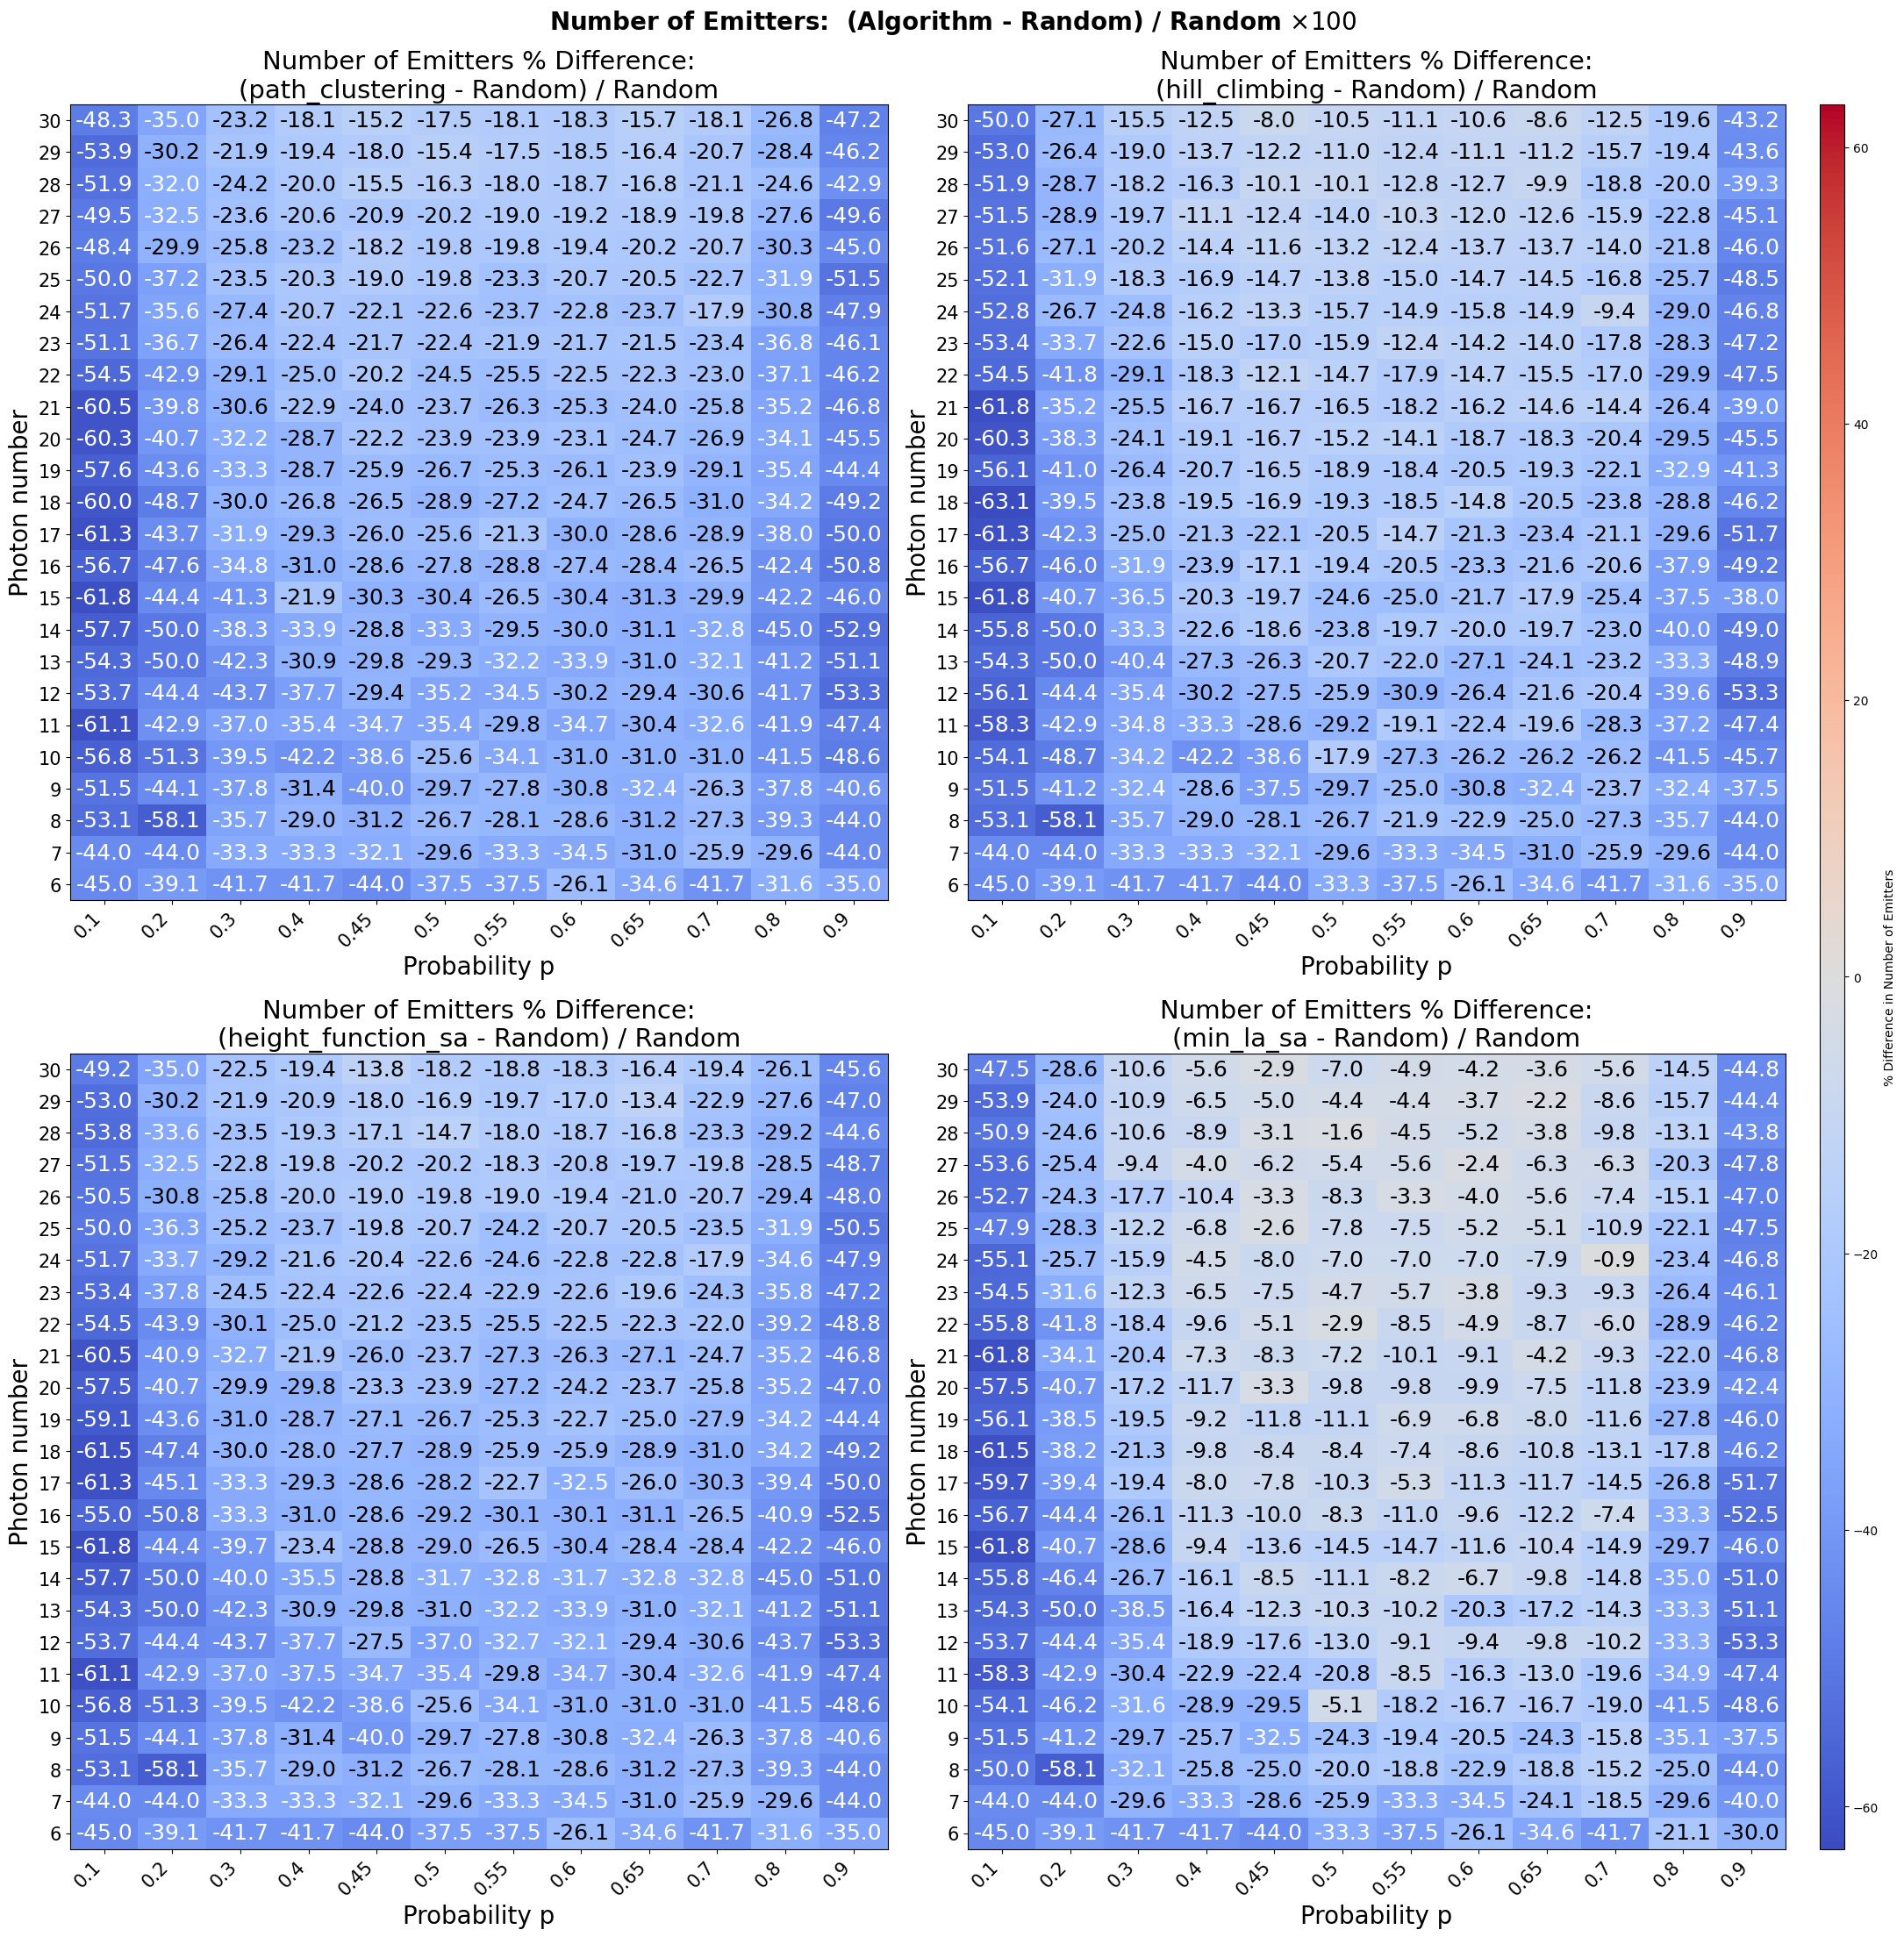

In [138]:
# ═══════════════════════════════════════════════════════════════════
# METRIC 1 — Number of Emitters
# ═══════════════════════════════════════════════════════════════════
plot_pct_diff_grid(
    metric_name='Number of Emitters',
    random_col='num_emitters_random',
    algo_col_template='num_emitters_{suffix}',
    algos=algos,
    prob_list=prob_list,
    nodes_list=nodes_list,
)

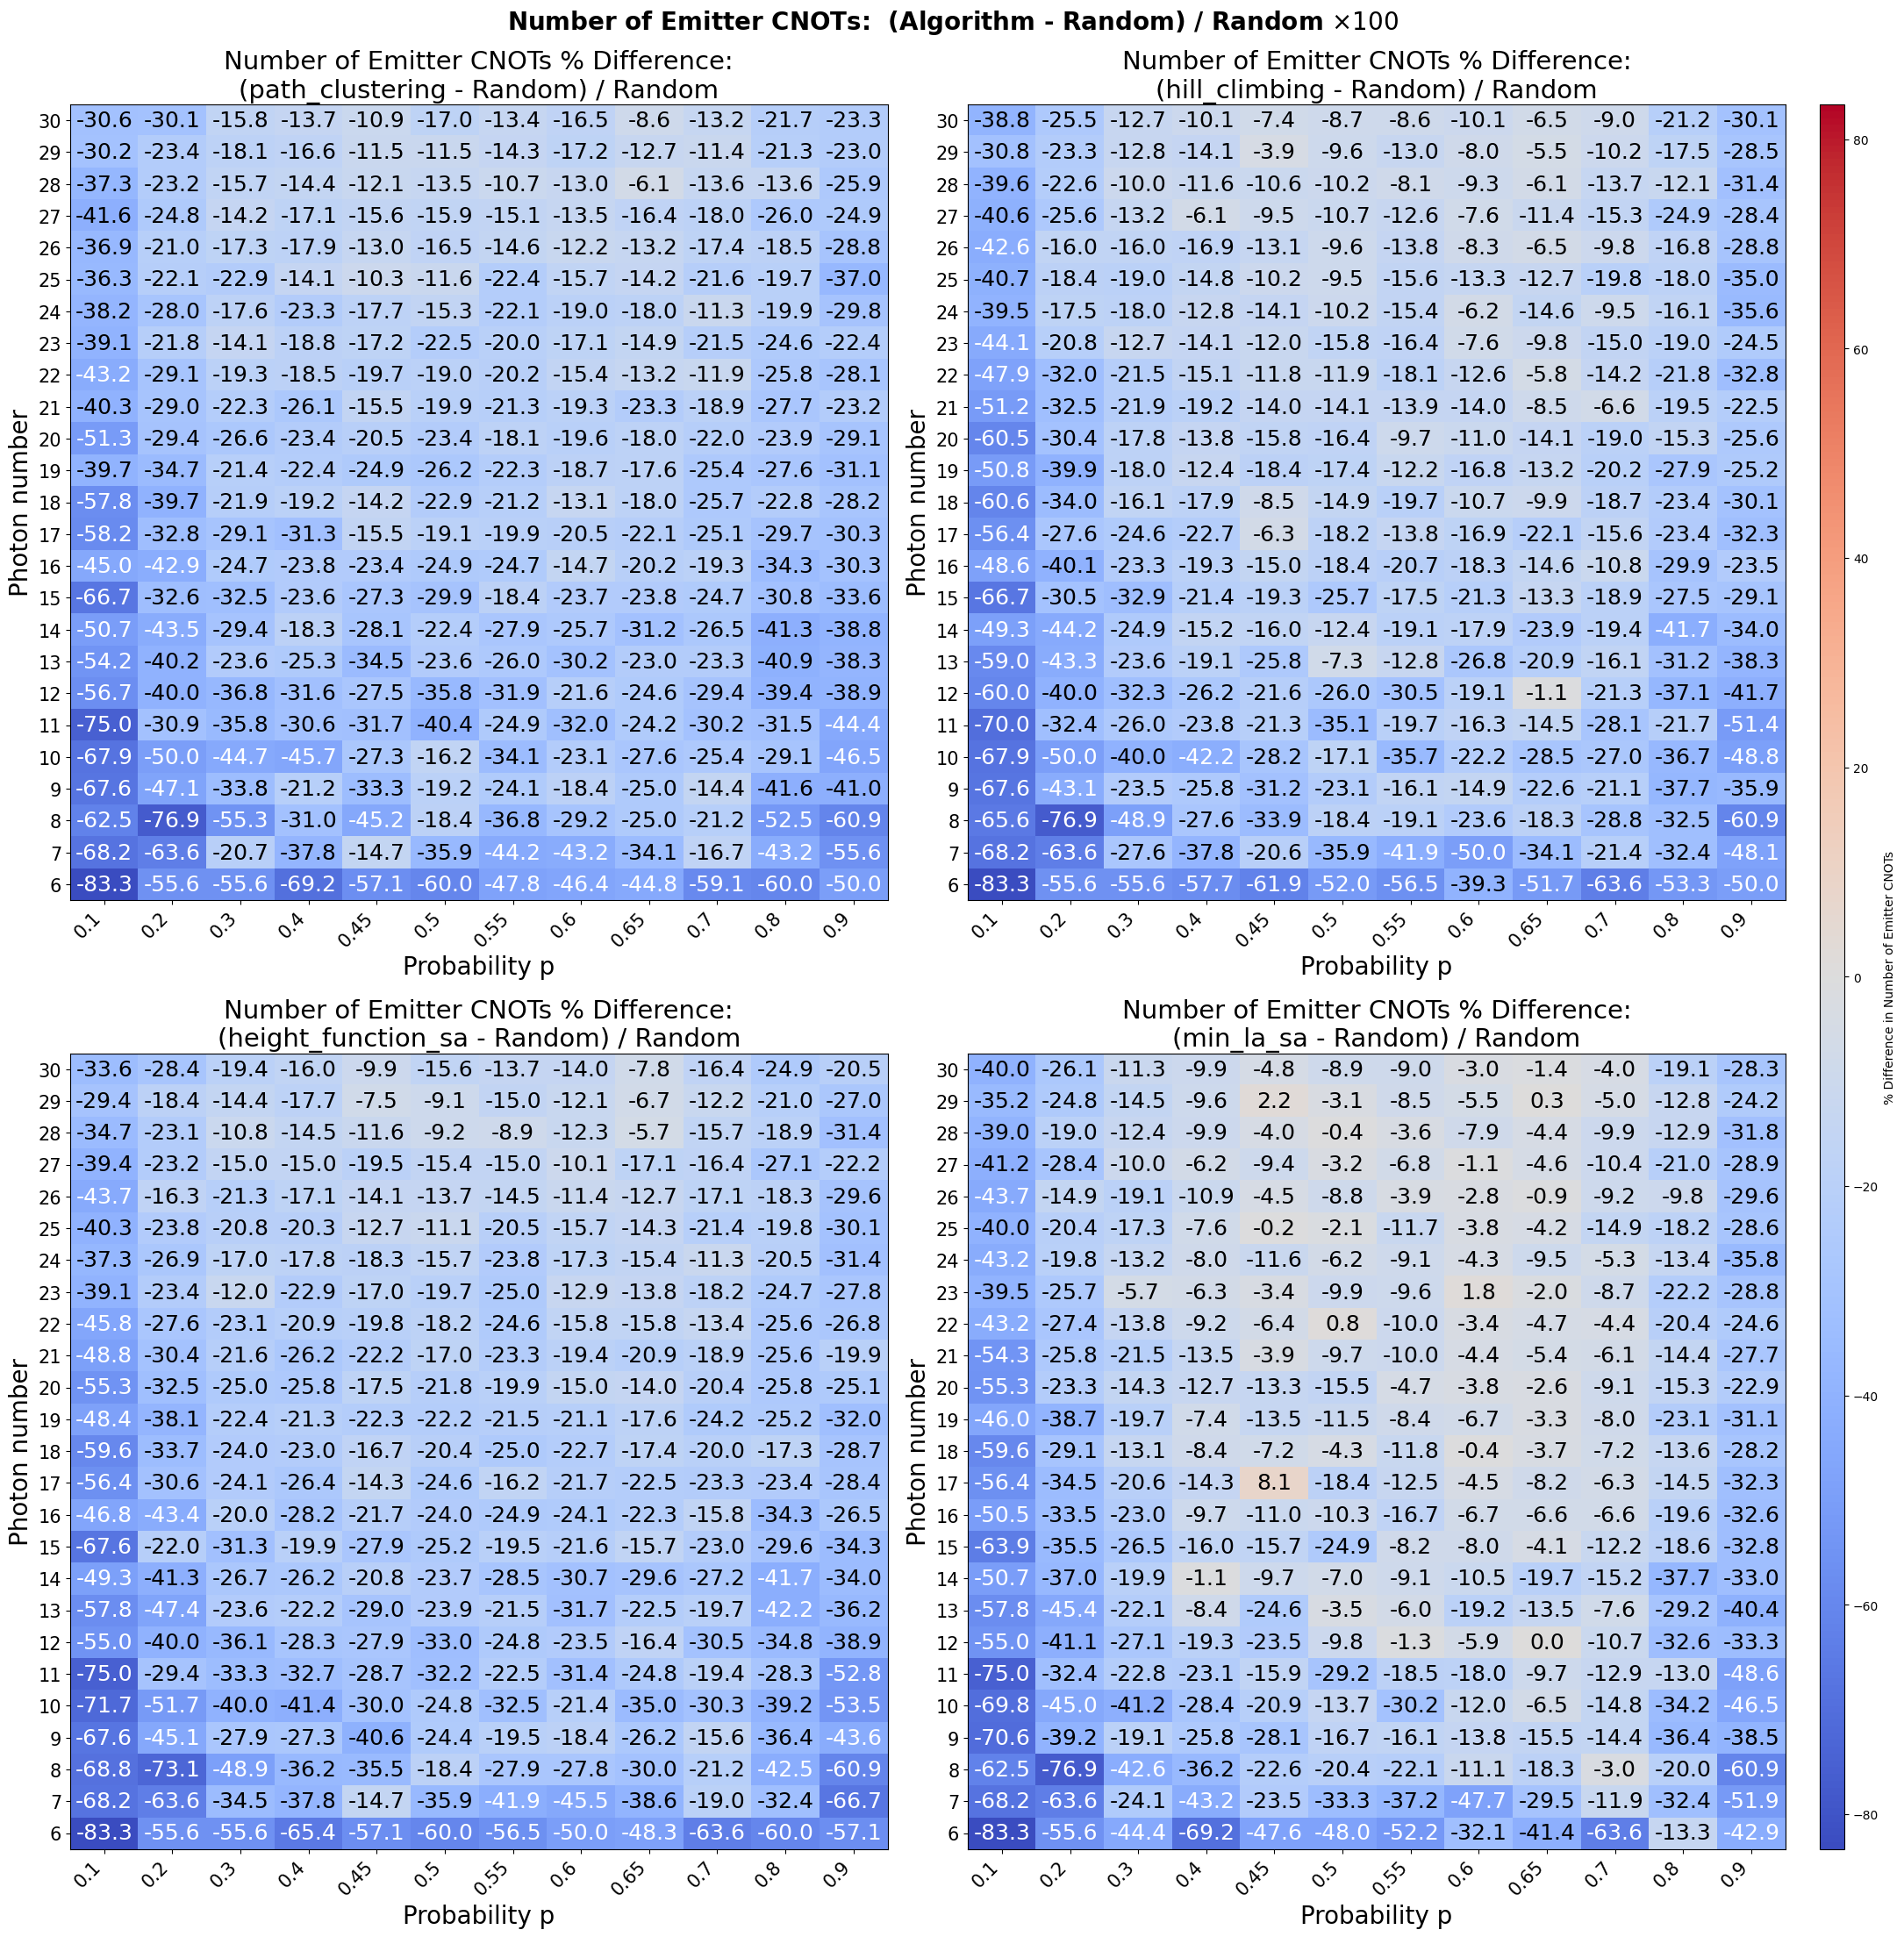

In [139]:
# ═══════════════════════════════════════════════════════════════════
# METRIC 2 — Number of Emitter CNOTs
# ═══════════════════════════════════════════════════════════════════
plot_pct_diff_grid(
    metric_name='Number of Emitter CNOTs',
    random_col='num_emitter_CNOTs_random',
    algo_col_template='num_emitter_CNOTs_{suffix}',
    algos=algos,
    prob_list=prob_list,
    nodes_list=nodes_list,
)

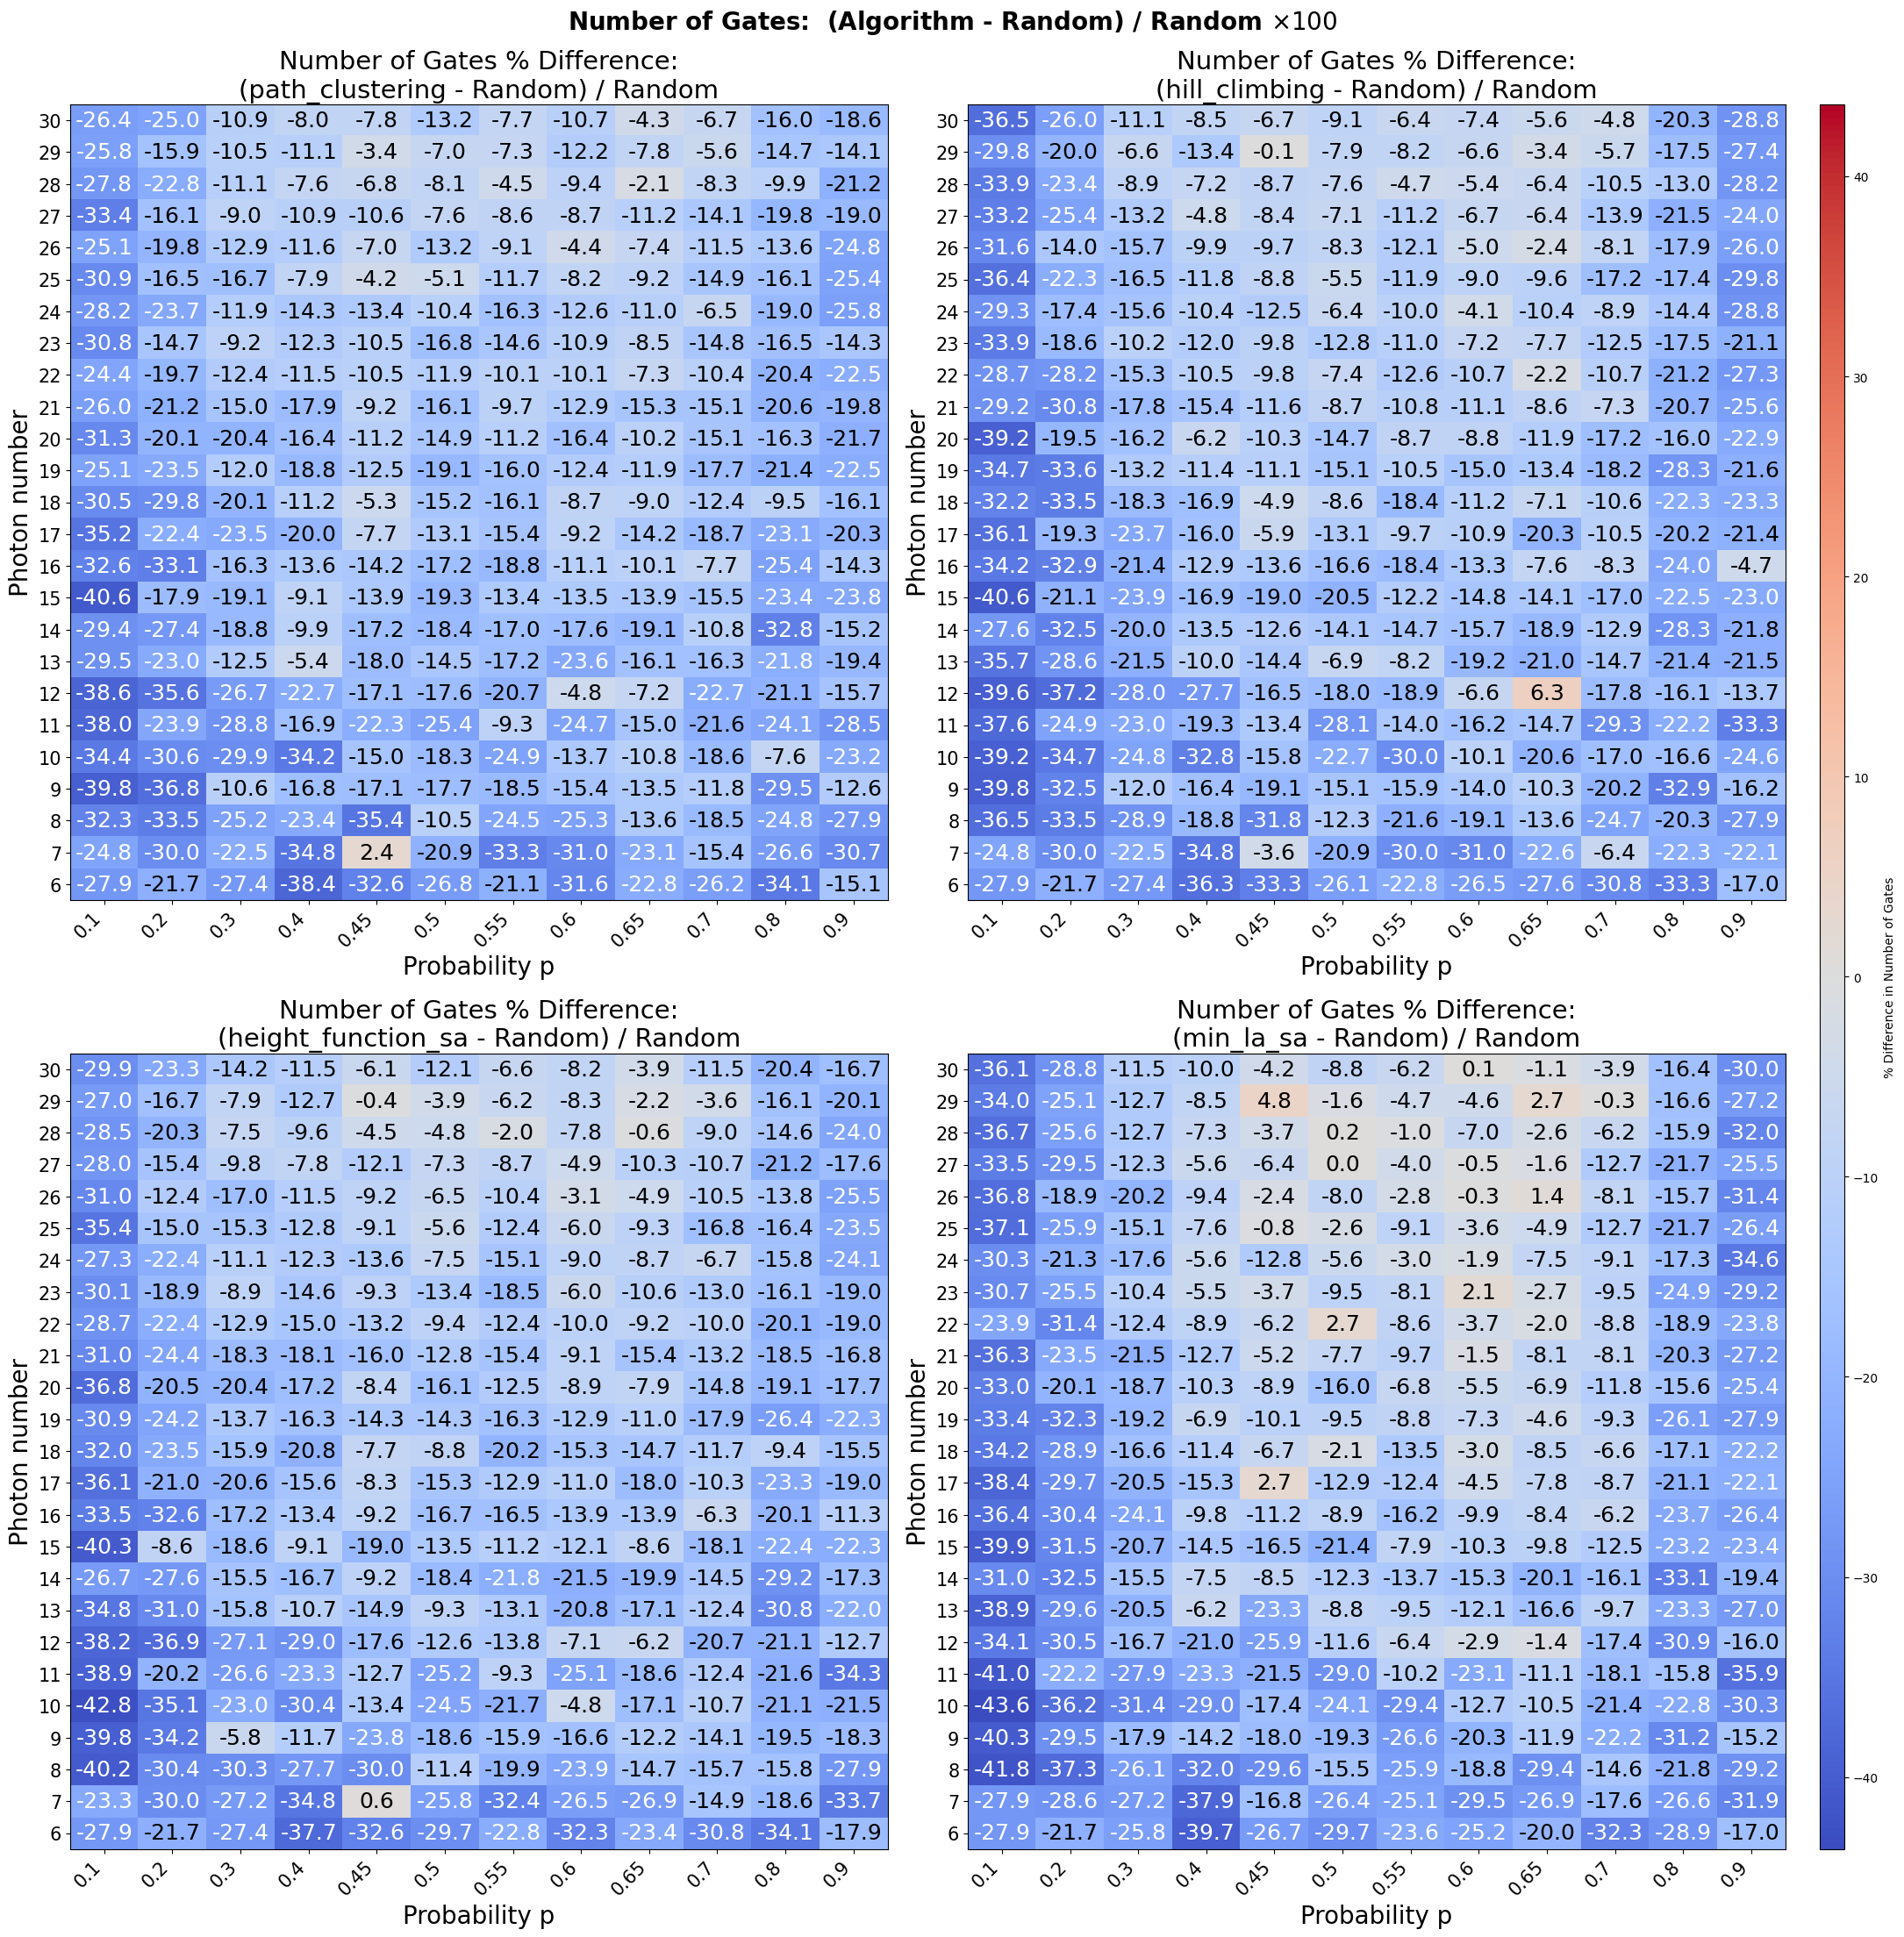

In [140]:
# ═══════════════════════════════════════════════════════════════════
# METRIC 3 — Number of Gates
# ═══════════════════════════════════════════════════════════════════
plot_pct_diff_grid(
    metric_name='Number of Gates',
    random_col='num_gates_random',
    algo_col_template='num_gates_{suffix}',
    algos=algos,
    prob_list=prob_list,
    nodes_list=nodes_list,
)

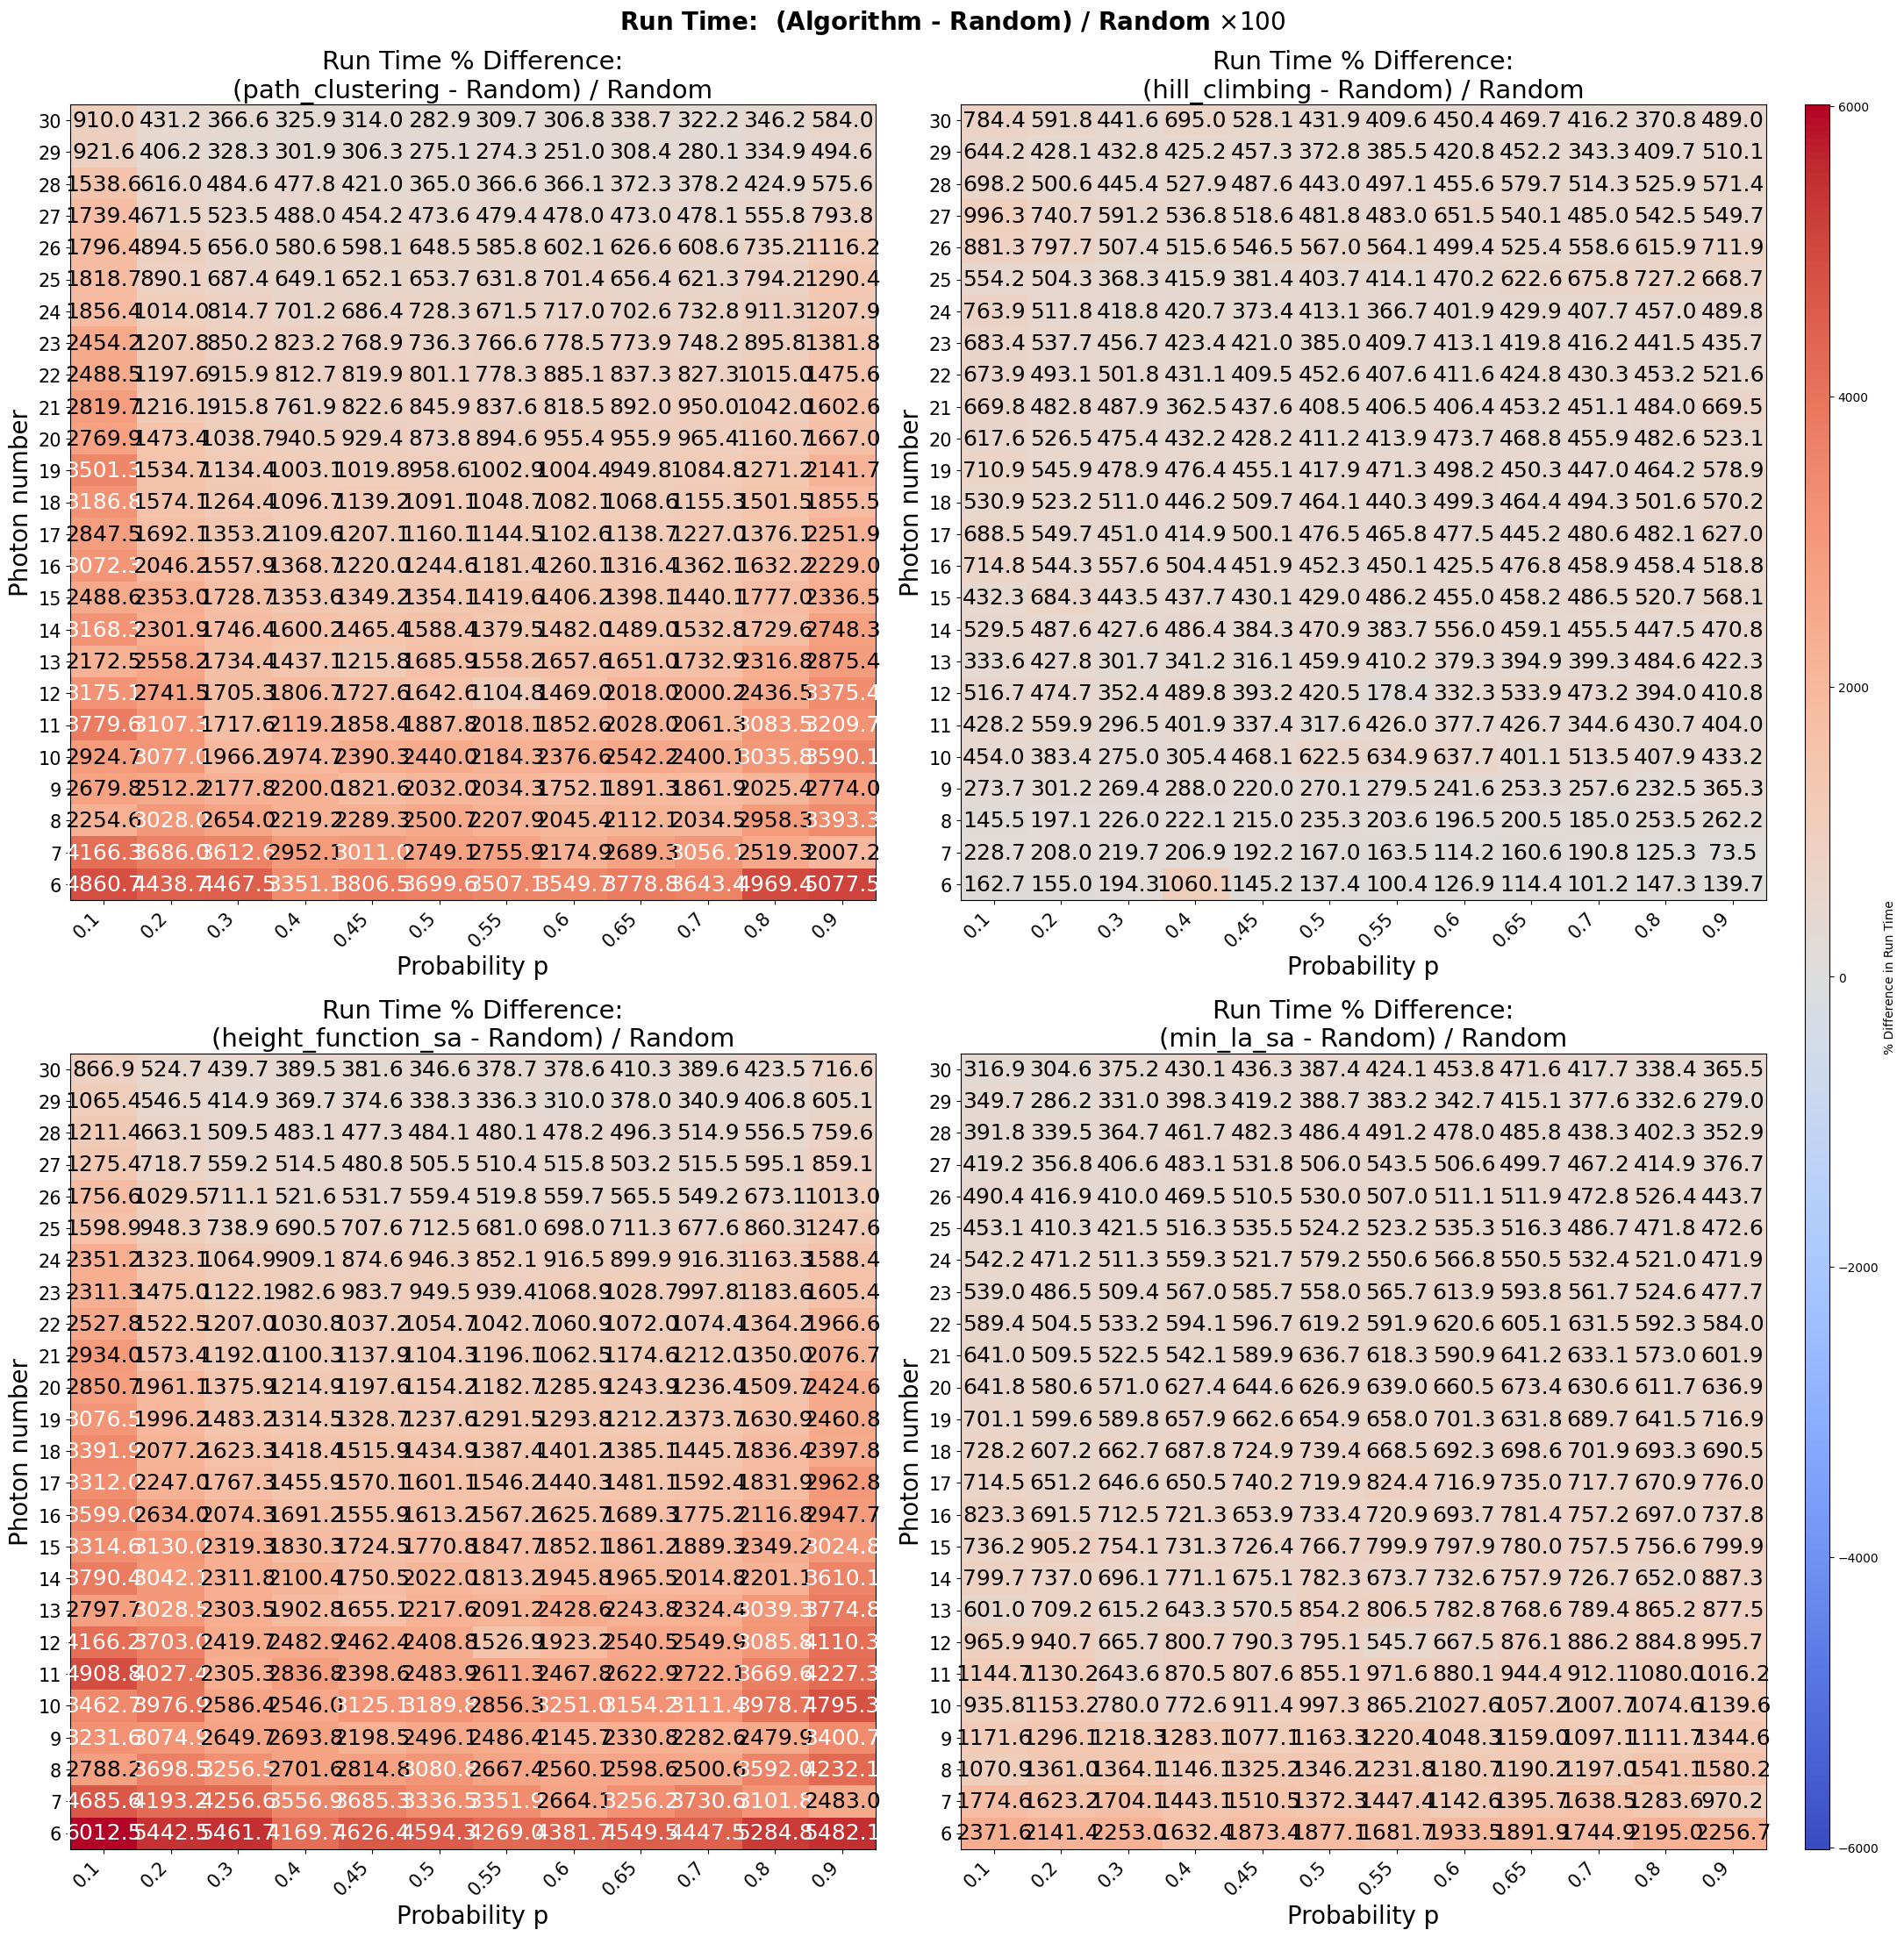

In [141]:
# ═══════════════════════════════════════════════════════════════════
# METRIC 4 — Run Time
# ═══════════════════════════════════════════════════════════════════
plot_pct_diff_grid(
    metric_name='Run Time',
    random_col='run_time_random',
    algo_col_template='run_time_{suffix}',
    algos=algos,
    prob_list=prob_list,
    nodes_list=nodes_list,
)

In [142]:
# ═══════════════════════════════════════════════════════════════════
# ANALYSIS SETUP — merge all CSVs on graph path, compute % differences
# ═══════════════════════════════════════════════════════════════════
from scipy import stats

ALGO_LABELS  = ['path_clustering', 'hill_climbing', 'height_function_sa', 'min_la_sa']
ALGO_SUFFIXES = ['path', 'rw', 'rw_sa', 'saminla']
ALGO_COLORS   = ['#2196F3', '#FF9800', '#9C27B0', '#4CAF50']

METRICS = [
    ('num_emitters',      'Emitters'),
    ('num_emitter_CNOTs', 'CNOTs'),
    ('num_gates',         'Gatecount'),
    ('run_time',          'Run Time'),
]

# ── merge all frames on graph path ─────────────────────────────────
key_cols = ['path', 'node_number', 'p']
merged = df_random[key_cols + [f'{m}_random' for m, _ in METRICS]].copy()
for df_algo, sfx in zip([df_path, df_rw, df_rw_sa, df_sam], ALGO_SUFFIXES):
    cols = [f'{m}_{sfx}' for m, _ in METRICS]
    merged = merged.merge(df_algo[['path'] + cols], on='path', how='inner')

merged['node_number'] = pd.to_numeric(merged['node_number'], errors='coerce')
merged['p'] = pd.to_numeric(merged['p'], errors='coerce')

# ── compute % difference columns: (algo - random) / random * 100 ──
for m, _ in METRICS:
    rnd = merged[f'{m}_random'].replace(0, np.nan)
    for sfx in ALGO_SUFFIXES:
        merged[f'pct_{m}_{sfx}'] = (merged[f'{m}_{sfx}'] - merged[f'{m}_random']) / rnd * 100.0

print(f"Merged: {merged.shape[0]} graphs  ×  {merged.shape[1]} columns")
print("% diff columns:", [c for c in merged.columns if c.startswith('pct_')])

Merged: 3000 graphs  ×  39 columns
% diff columns: ['pct_num_emitters_path', 'pct_num_emitters_rw', 'pct_num_emitters_rw_sa', 'pct_num_emitters_saminla', 'pct_num_emitter_CNOTs_path', 'pct_num_emitter_CNOTs_rw', 'pct_num_emitter_CNOTs_rw_sa', 'pct_num_emitter_CNOTs_saminla', 'pct_num_gates_path', 'pct_num_gates_rw', 'pct_num_gates_rw_sa', 'pct_num_gates_saminla', 'pct_run_time_path', 'pct_run_time_rw', 'pct_run_time_rw_sa', 'pct_run_time_saminla']


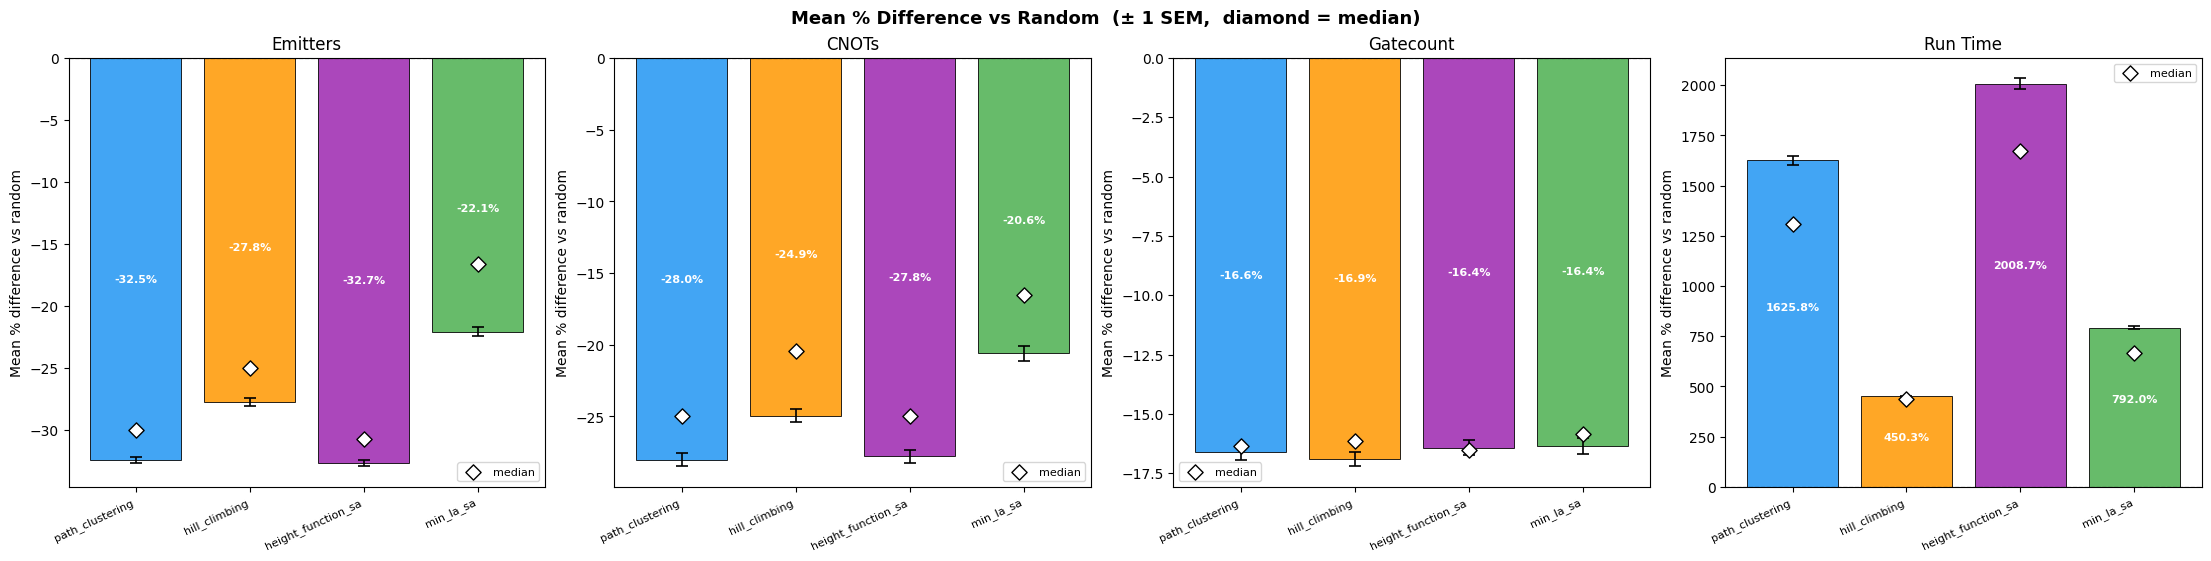

In [143]:
# ═══════════════════════════════════════════════════════════════════
# PLOT A — Summary bar chart: mean % difference vs random per metric
# ═══════════════════════════════════════════════════════════════════
n_metrics = len(METRICS)
fig, axes = plt.subplots(1, n_metrics, figsize=(5.5 * n_metrics, 5.5), constrained_layout=True)

for ax, (m, m_label) in zip(axes, METRICS):
    means   = [merged[f'pct_{m}_{sfx}'].mean()   for sfx in ALGO_SUFFIXES]
    sems    = [merged[f'pct_{m}_{sfx}'].sem()    for sfx in ALGO_SUFFIXES]
    medians = [merged[f'pct_{m}_{sfx}'].median() for sfx in ALGO_SUFFIXES]

    x = np.arange(len(ALGO_LABELS))
    bars = ax.bar(x, means, yerr=sems, capsize=4, error_kw=dict(elinewidth=1.2, capthick=1.2),
                  color=ALGO_COLORS, edgecolor='black', linewidth=0.7, alpha=0.85)

    # median as a white diamond
    ax.scatter(x, medians, color='white', edgecolors='black',
               zorder=5, s=60, marker='D', label='median')

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xticks(x)
    ax.set_xticklabels(ALGO_LABELS, rotation=25, ha='right', fontsize=8)
    ax.set_ylabel('Mean % difference vs random')
    ax.set_title(m_label)

    # annotate at mid-bar (inside the bar), always clear of the error cap
    for i_b, (bar, mean_val) in enumerate(zip(bars, means)):
        bar_h = bar.get_height()   # signed height
        # place label at 50% of the bar, offset slightly toward the baseline
        label_y = mean_val * 0.55
        ax.text(bar.get_x() + bar.get_width() / 2, label_y,
                f'{mean_val:.1f}%', ha='center', va='center',
                fontsize=8, fontweight='bold',
                color='white')

    ax.legend(fontsize=8)

fig.suptitle('Mean % Difference vs Random  (± 1 SEM,  diamond = median)',
             fontsize=13, fontweight='bold')
plt.show()

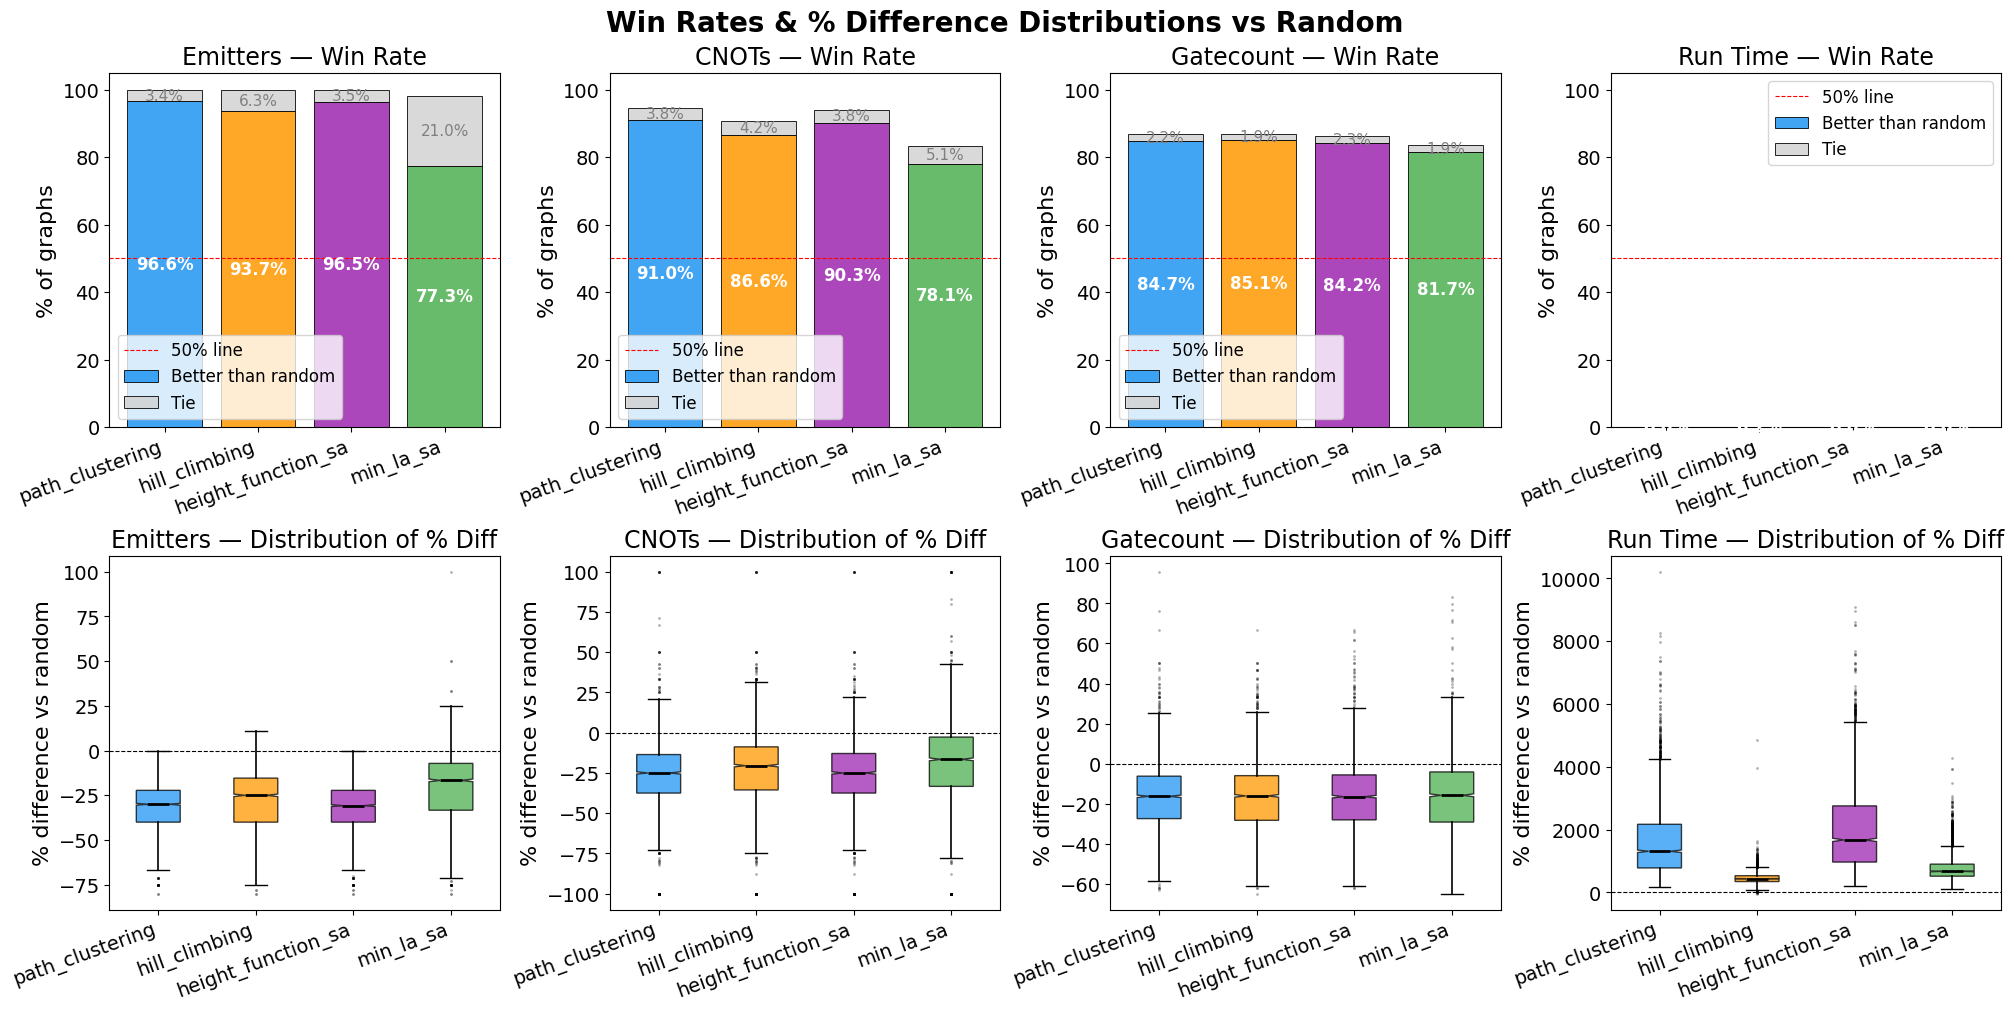

In [144]:
# ═══════════════════════════════════════════════════════════════════
# PLOT B — Win-rate heatmap: % of graphs where algo beats random
#           + box-plots of the % difference distributions
# ═══════════════════════════════════════════════════════════════════

LABEL_SIZE = 16
TITLE_SIZE = 17
TICK_SIZE = 14
LEGEND_SIZE = 12
SUPTITLE_SIZE = 20
BAR_TEXT_SIZE = 12
TIE_TEXT_SIZE = 11

fig, axes = plt.subplots(
    2, n_metrics,
    figsize=(5 * n_metrics, 10),
    constrained_layout=True
)

for col_idx, (m, m_label) in enumerate(METRICS):
    # ── top row: win-rate bar ────────────────────────────────────────
    ax_top = axes[0, col_idx]
    win_rates = []
    tie_rates = []

    for sfx in ALGO_SUFFIXES:
        algo_col = merged[f'{m}_{sfx}']
        rnd_col  = merged[f'{m}_random']
        win_rates.append((algo_col < rnd_col).mean() * 100)
        tie_rates.append((algo_col == rnd_col).mean() * 100)

    x = np.arange(len(ALGO_LABELS))
    tie_array = np.array(tie_rates)
    win_array = np.array(win_rates)

    ax_top.bar(
        x,
        win_array,
        color=ALGO_COLORS,
        edgecolor='black',
        linewidth=0.7,
        alpha=0.85,
        label='Better than random'
    )

    ax_top.bar(
        x,
        tie_array,
        bottom=win_array,
        color='lightgrey',
        edgecolor='black',
        linewidth=0.7,
        alpha=0.85,
        label='Tie'
    )

    for xi, (w, t) in enumerate(zip(win_array, tie_array)):
        ax_top.text(
            xi,
            w / 2,
            f'{w:.1f}%',
            ha='center',
            va='center',
            fontsize=BAR_TEXT_SIZE,
            fontweight='bold',
            color='white'
        )

        if t > 0.5:
            ax_top.text(
                xi,
                w + t / 2,
                f'{t:.1f}%',
                ha='center',
                va='center',
                fontsize=TIE_TEXT_SIZE,
                color='grey'
            )

    ax_top.axhline(
        50,
        color='red',
        linestyle='--',
        linewidth=0.8,
        label='50% line'
    )

    ax_top.set_ylim(0, 105)
    ax_top.set_xticks(x)
    ax_top.set_xticklabels(
        ALGO_LABELS,
        rotation=20,
        ha='right',
        fontsize=TICK_SIZE
    )

    ax_top.set_ylabel('% of graphs', fontsize=LABEL_SIZE)
    ax_top.set_title(f'{m_label} — Win Rate', fontsize=TITLE_SIZE)
    ax_top.tick_params(axis='both', labelsize=TICK_SIZE)
    ax_top.legend(fontsize=LEGEND_SIZE)

    # ── bottom row: box plots of % diff ─────────────────────────────
    ax_bot = axes[1, col_idx]

    data_to_plot = [
        merged[f'pct_{m}_{sfx}'].dropna().values
        for sfx in ALGO_SUFFIXES
    ]

    bp = ax_bot.boxplot(
        data_to_plot,
        patch_artist=True,
        notch=True,
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(linewidth=1.2),
        flierprops=dict(marker='.', markersize=2, alpha=0.3)
    )

    for patch, color in zip(bp['boxes'], ALGO_COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    ax_bot.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax_bot.set_xticks(range(1, len(ALGO_LABELS) + 1))
    ax_bot.set_xticklabels(
        ALGO_LABELS,
        rotation=20,
        ha='right',
        fontsize=TICK_SIZE
    )

    ax_bot.set_ylabel('% difference vs random', fontsize=LABEL_SIZE)
    ax_bot.set_title(
        f'{m_label} — Distribution of % Diff',
        fontsize=TITLE_SIZE
    )
    ax_bot.tick_params(axis='both', labelsize=TICK_SIZE)

fig.suptitle(
    'Win Rates & % Difference Distributions vs Random',
    fontsize=SUPTITLE_SIZE,
    fontweight='bold'
)

plt.show()

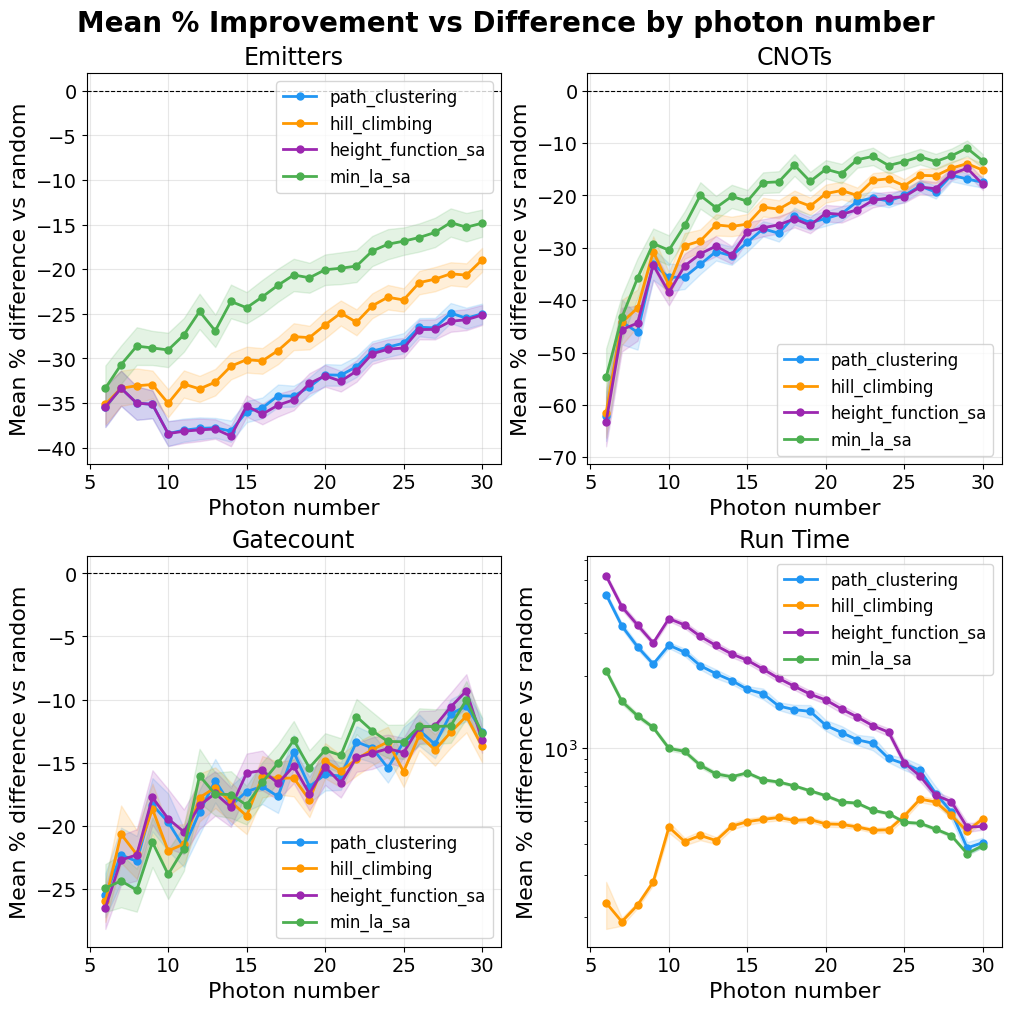

In [145]:
# ═══════════════════════════════════════════════════════════════════
# PLOT C — Mean % improvement vs random as a function of graph size
#           (one subplot per metric, one line per algorithm)
# ═══════════════════════════════════════════════════════════════════

LABEL_SIZE = 16
TITLE_SIZE = 17
TICK_SIZE = 14
LEGEND_SIZE = 12
SUPTITLE_SIZE = 20

fig, axes = plt.subplots(2, 2, figsize=(10, 10),
                         constrained_layout=True, sharey=False)

for ax, (m, m_label) in zip(axes.flat, METRICS):
    for sfx, label, color in zip(ALGO_SUFFIXES, ALGO_LABELS, ALGO_COLORS):
        col = f'pct_{m}_{sfx}'
        grp = merged.groupby('node_number')[col].agg(['mean', 'sem']).reset_index()

        ax.plot(
            grp['node_number'],
            grp['mean'],
            marker='o',
            markersize=5,
            label=label,
            color=color,
            linewidth=2
        )

        ax.fill_between(
            grp['node_number'],
            grp['mean'] - grp['sem'],
            grp['mean'] + grp['sem'],
            alpha=0.15,
            color=color
        )

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

    ax.set_xlabel('Photon number', fontsize=LABEL_SIZE)
    ax.set_ylabel('Mean % difference vs random', fontsize=LABEL_SIZE)
    ax.set_title(m_label, fontsize=TITLE_SIZE)

    ax.tick_params(axis='both', labelsize=TICK_SIZE)

    ax.legend(fontsize=LEGEND_SIZE)
    ax.grid(True, alpha=0.3)

    if m == 'run_time':
        ax.set_yscale('log')

for ax in axes.flat[len(METRICS):]:
    ax.set_visible(False)

fig.suptitle(
    'Mean % Improvement vs Difference by photon number',
    fontsize=SUPTITLE_SIZE,
    fontweight='bold'
)

plt.show()

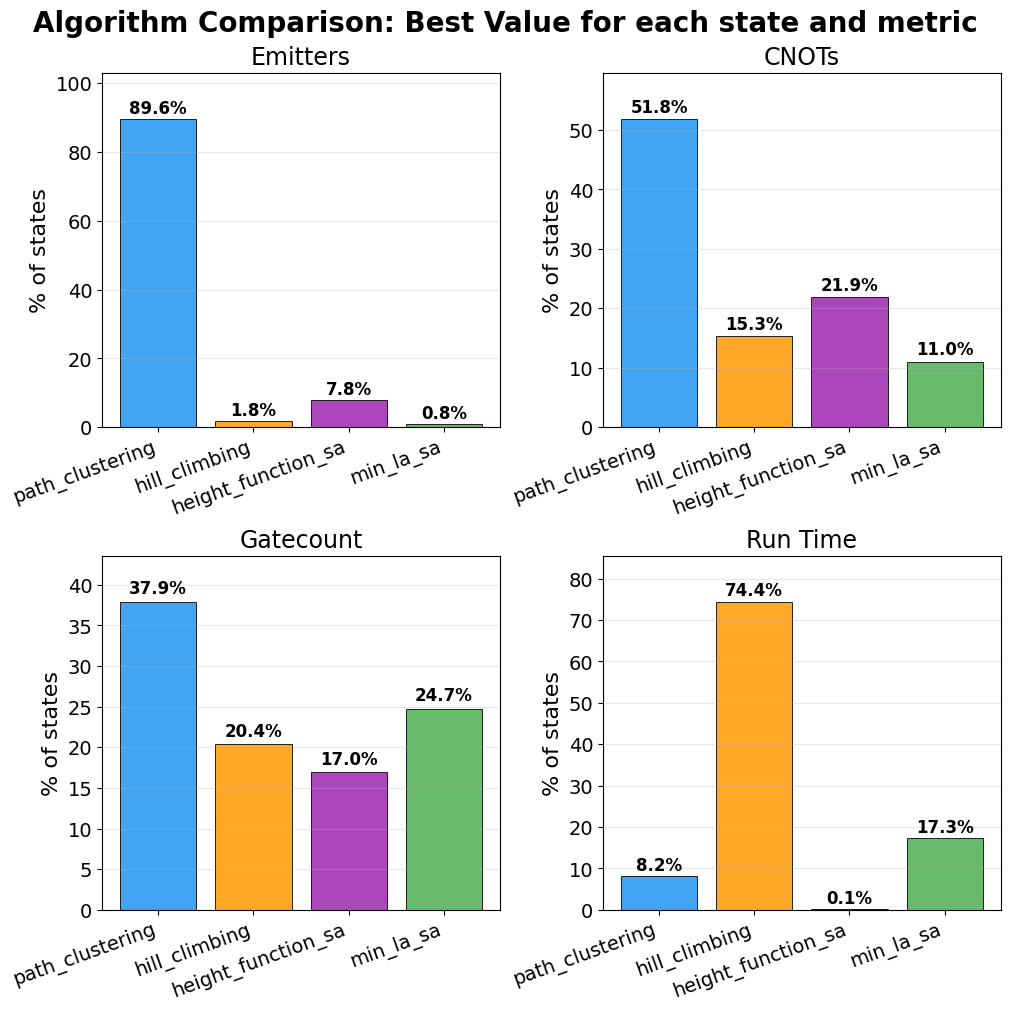

In [146]:
# ═══════════════════════════════════════════════════════════════════
# PLOT D — Head-to-head scatter: which algorithm achieves the best
#           value on EACH graph instance, for each metric
# ═══════════════════════════════════════════════════════════════════

LABEL_SIZE = 16
TITLE_SIZE = 17
TICK_SIZE = 14
BAR_TEXT_SIZE = 12
SUPTITLE_SIZE = 20

fig, axes = plt.subplots(
    2,
    2,
    figsize=(10, 10),
    constrained_layout=True
)

for ax, (m, m_label) in zip(axes.flat, METRICS):
    algo_cols = [f'{m}_{sfx}' for sfx in ALGO_SUFFIXES]

    # find which algorithm achieves the minimum on each row
    best_idx = merged[algo_cols].values.argmin(axis=1)

    counts = np.bincount(best_idx, minlength=len(ALGO_LABELS))
    pcts = counts / counts.sum() * 100

    bars = ax.bar(
        ALGO_LABELS,
        pcts,
        color=ALGO_COLORS,
        edgecolor='black',
        linewidth=0.7,
        alpha=0.85
    )

    for bar, pct in zip(bars, pcts):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{pct:.1f}%',
            ha='center',
            va='bottom',
            fontsize=BAR_TEXT_SIZE,
            fontweight='bold'
        )

    ax.set_ylim(0, max(pcts) * 1.15)

    ax.set_xticks(range(len(ALGO_LABELS)))
    ax.set_xticklabels(
        ALGO_LABELS,
        rotation=20,
        ha='right',
        fontsize=TICK_SIZE
    )

    ax.set_ylabel('% of states', fontsize=LABEL_SIZE)
    ax.set_title(f'{m_label}', fontsize=TITLE_SIZE)

    ax.tick_params(axis='both', labelsize=TICK_SIZE)
    ax.grid(axis='y', alpha=0.3)

for ax in axes.flat[len(METRICS):]:
    ax.set_visible(False)

fig.suptitle(
    'Algorithm Comparison: Best Value for each state and metric',
    fontsize=SUPTITLE_SIZE,
    fontweight='bold'
)

plt.show()

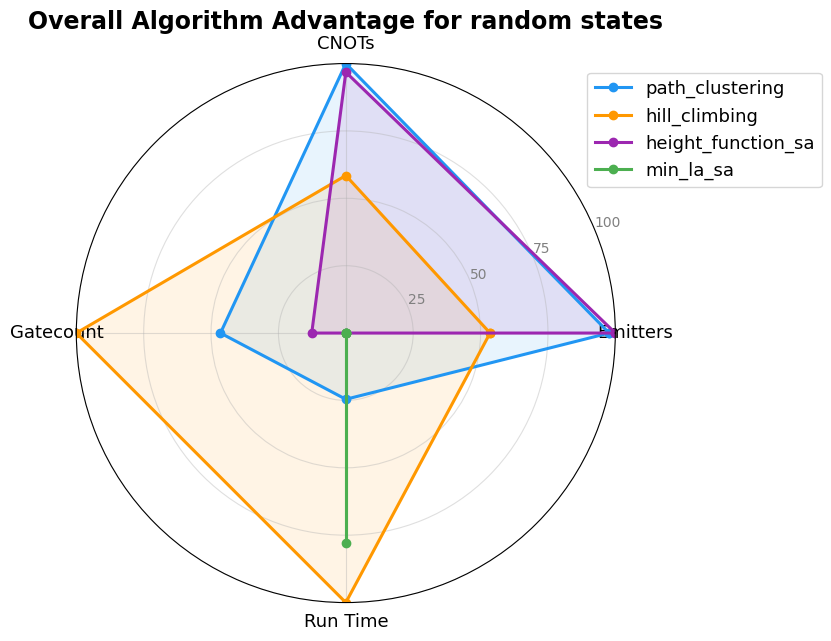


── SUMMARY TABLE: mean % improvement over random (negative = fewer resources) ──
Algorithm                           Emitters                 CNOTs             Gatecount              Run Time
--------------------------------------------------------------------------------------------------------------
path_clustering                      -32.46%               -28.04%               -16.61%             +1625.77%
hill_climbing                        -27.78%               -24.95%               -16.90%              +450.33%
height_function_sa                   -32.70%               -27.80%               -16.43%             +2008.68%
min_la_sa                            -22.11%               -20.60%               -16.36%              +791.97%

  Negative values = algorithm uses fewer resources than random.
  Run Time is always positive, because optimisation adds overhead over the trivial ordering.


In [147]:
# ═══════════════════════════════════════════════════════════════════
# PLOT E — Radar / spider chart: overall algorithm ranking per metric
#           Score per axis = rank (1 = best) averaged across all graphs,
#           then inverted so higher = better on the chart.
#           Run Time is treated separately (lower overhead is better).
# ═══════════════════════════════════════════════════════════════════

LABEL_SIZE = 15
TITLE_SIZE = 17
TICK_SIZE = 13
RADIAL_TICK_SIZE = 10
LEGEND_SIZE = 13

# ── Build mean % improvement table ─────────────────────────────────
mean_pct = {}

for sfx, label in zip(ALGO_SUFFIXES, ALGO_LABELS):
    mean_pct[label] = [
        -merged[f'pct_{m}_{sfx}'].mean()
        for m, _ in METRICS
    ]
    # sign-flip: negative pct diff → positive improvement score

# Normalise each axis to [0, 100] so axes are comparable
metric_labels = [ml for _, ml in METRICS]
n_metrics_r = len(metric_labels)

scores_norm = {}

for label in ALGO_LABELS:
    scores_norm[label] = []

for idx in range(n_metrics_r):
    vals = np.array([
        mean_pct[label][idx]
        for label in ALGO_LABELS
    ])

    v_min, v_max = vals.min(), vals.max()

    if v_max == v_min:
        normed = np.full_like(vals, 50.0)
    else:
        normed = (vals - v_min) / (v_max - v_min) * 100.0

    for label, nv in zip(ALGO_LABELS, normed):
        scores_norm[label].append(float(nv))

# ── Radar plot ──────────────────────────────────────────────────────
N = n_metrics_r

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(
    figsize=(7, 7),
    subplot_kw=dict(polar=True)
)

for label, color in zip(ALGO_LABELS, ALGO_COLORS):
    values = scores_norm[label] + scores_norm[label][:1]

    ax.plot(
        angles,
        values,
        color=color,
        linewidth=2.2,
        label=label,
        marker='o',
        markersize=6
    )

    ax.fill(
        angles,
        values,
        color=color,
        alpha=0.10
    )

ax.set_xticks(angles[:-1])
ax.set_xticklabels(
    metric_labels,
    fontsize=LABEL_SIZE
)

ax.set_ylim(0, 100)
ax.set_yticks([25, 50, 75, 100])
ax.set_yticklabels(
    ['25', '50', '75', '100'],
    fontsize=RADIAL_TICK_SIZE,
    color='grey'
)

ax.tick_params(axis='x', labelsize=TICK_SIZE)
ax.tick_params(axis='y', labelsize=RADIAL_TICK_SIZE)

ax.set_title(
    'Overall Algorithm Advantage for random states',
    fontsize=TITLE_SIZE,
    fontweight='bold',
    pad=25
)

ax.legend(
    loc='upper right',
    bbox_to_anchor=(1.40, 1.0),
    fontsize=LEGEND_SIZE
)

ax.grid(True, alpha=0.4)

plt.show()

# ── Print a clean summary table ─────────────────────────────────────
print("\n── SUMMARY TABLE: mean % improvement over random (negative = fewer resources) ──")

header = f"{'Algorithm':22s}" + "".join(
    f"{ml:>22s}"
    for _, ml in METRICS
)

print(header)
print("-" * len(header))

for label in ALGO_LABELS:
    row = f"{label:22s}"

    for idx, (m, _) in enumerate(METRICS):
        val = merged[
            f'pct_{m}_{ALGO_SUFFIXES[ALGO_LABELS.index(label)]}'
        ].mean()

        row += f"{val:>+21.2f}%"

    print(row)

print("\n  Negative values = algorithm uses fewer resources than random.")
print("  Run Time is always positive, because optimisation adds overhead over the trivial ordering.")

In [148]:
# ═══════════════════════════════════════════════════════════════════
# BUG-FIX CHECK — is graph_stats_path_clustering_fix_bug.csv statistically
#                 different from the original graph_stats_path_clustering.csv?
# ═══════════════════════════════════════════════════════════════════
from scipy import stats

df_rw_orig  = pd.read_csv(os.path.join(base, 'graph_stats_path_clustering.csv'))
df_rw_fixed = pd.read_csv(os.path.join(base, 'graph_stats_path_clustering_fix_bug.csv'))

BUGFIX_METRICS = ['num_emitters_path', 'num_emitter_CNOTs_path', 'num_gates_path', 'run_time_path']

# ── pair rows on the same graph (path) so we can run a paired test ──
paired = df_rw_orig[['path'] + BUGFIX_METRICS].merge(
    df_rw_fixed[['path'] + BUGFIX_METRICS],
    on='path', suffixes=('_orig', '_fixed')
)

print(f"Paired on {len(paired)} graphs (orig: {len(df_rw_orig)}, fixed: {len(df_rw_fixed)})\n")

header = f"{'Metric':22s}{'mean orig':>14s}{'mean fixed':>14s}{'mean Δ':>12s}{'Wilcoxon p':>14s}{'paired t p':>14s}"
print(header)
print('-' * len(header))

for metric in BUGFIX_METRICS:
    orig_vals  = paired[f'{metric}_orig']
    fixed_vals = paired[f'{metric}_fixed']
    mask = orig_vals.notna() & fixed_vals.notna()
    o, f = orig_vals[mask], fixed_vals[mask]

    diff = f - o
    mean_orig, mean_fixed, mean_diff = o.mean(), f.mean(), diff.mean()

    # Wilcoxon signed-rank needs at least one non-zero difference
    if (diff != 0).any():
        w_p = stats.wilcoxon(o, f).pvalue
    else:
        w_p = float('nan')

    t_p = stats.ttest_rel(o, f).pvalue

    print(f"{metric:22s}{mean_orig:>14.3f}{mean_fixed:>14.3f}{mean_diff:>+12.3f}{w_p:>14.4g}{t_p:>14.4g}")

print("\n  p < 0.05 on either test, this means the bug fix produced a statistically significant change.")
print("  mean Δ = mean(fixed) - mean(orig), negative = fixed version uses fewer resources / less time.")


Paired on 3000 graphs (orig: 3000, fixed: 3000)

Metric                     mean orig    mean fixed      mean Δ    Wilcoxon p    paired t p
------------------------------------------------------------------------------------------
num_emitters_path              5.475         5.488      +0.013        0.0828       0.08288
num_emitter_CNOTs_path        45.107        45.294      +0.187         0.471        0.1837
num_gates_path               122.150       122.517      +0.367        0.2715        0.2768
run_time_path                  6.565         8.221      +1.656    1.281e-265    9.156e-193

  p < 0.05 on either test, this means the bug fix produced a statistically significant change.
  mean Δ = mean(fixed) - mean(orig), negative = fixed version uses fewer resources / less time.
